In [12]:
from sklearn.model_selection import train_test_split # import train_test_split from sklearn.model_selection to split the dataset intro traininf and test set
from sklearn.tree import DecisionTreeClassifier # import the decision tree classifier from sklearn.tree
from sklearn.ensemble import RandomForestClassifier #import the random forest classifier form sklearn.ensemble
from sklearn.naive_bayes import GaussianNB # import Gaussian Naive bayes form sklearn.naive_bayes
from sklearn.neighbors import KNeighborsClassifier #import k Nearest Neighbor classifier form sklearn.neighbors
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix # from sklearn.metrics, we import accuracy-score and confusion_matrix

import matplotlib.pyplot as plt #library to plot results 
import seaborn as sns #import seaborn for statistical graphics 
import pandas as pd
import numpy as np 
from sklearn.tree import plot_tree

In [13]:
data_df = pd.read_csv("SpotifyDataset_withNA.csv")

In [14]:
data_df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [15]:
data_df.isna().sum().sort_values(ascending = False)

loudness            9
valence             7
album_name          1
track_name          1
artists             1
track_id            0
Unnamed: 0          0
explicit            0
popularity          0
danceability        0
energy              0
key                 0
duration_ms         0
mode                0
speechiness         0
instrumentalness    0
acousticness        0
liveness            0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [16]:
#drop missing values for specific columns: df = df.dropna(subset=['col1', 'col2'])
data_df = data_df.dropna()

In [17]:
data_df.isna().sum().sort_values(ascending = False)

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [18]:
column_names = data_df.columns.values.tolist()
feature_names = column_names[:-1]
feature_names

['Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

In [19]:
# Select Musical Features to Use for Classification
musical_features = [
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

data_df[musical_features]

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...
113995,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [20]:
#Select some track genres to Classifiy : 

#selected_genres =  ['children', 'chill', 'classical', 'dance', 'disco', 'electronic', 
                    # 'guitar', 'happy','hip-hop', 'jazz','metal', 'opera', 'piano', 'rock','romance', 'sad']

selected_genres =  ['happy','sad']

In [21]:
filtered_df = data_df[data_df['track_genre'].isin(selected_genres)].copy()
filtered_df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
46000,46000,6iBL6TOzsO75Yz0cG1MO0o,The Prophet,Wanna Play?,Wanna Play?,65,201451,False,0.569,0.996,...,-0.450,1,0.2240,0.198000,0.011400,0.7070,0.461,100.020,3,happy
46001,46001,2d9EgBM9F09IkEG8t9T6L8,Darren Styles;TNT,DLMD,DLMD,59,160212,False,0.487,0.990,...,-2.282,1,0.0940,0.000595,0.843000,0.3310,0.161,160.046,4,happy
46002,46002,6RvTtRyn7zVayLUWAJxd5Z,S3RL,Hentai,Hentai,55,185830,False,0.496,0.760,...,-4.281,1,0.3930,0.000799,0.002850,0.3680,0.422,174.944,4,happy
46003,46003,0L0DM33NAe6PjQ1BB4cEjJ,Darren Styles,Us Against The World,Us Against The World,62,271058,False,0.531,0.896,...,-3.297,0,0.1070,0.031600,0.007230,0.0297,0.340,169.955,4,happy
46004,46004,4tV6ku4jEYw9L5gZuNpCbP,Gammer;Darren Styles,DYSYLM,DYSYLM,57,176051,False,0.532,0.878,...,-3.933,0,0.2150,0.010200,0.201000,0.1690,0.385,169.962,4,happy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,94995,4DqNBM2oUr5R87cUd2E3P6,Josh A,LONELY VIBES (Deluxe),PTSD,41,121867,False,0.644,0.637,...,-7.922,1,0.0898,0.382000,0.000000,0.1410,0.216,81.479,4,sad
94996,94996,6HdrRVMieDZtv0vldfZxqg,Rarin,Day Ones,Day Ones,47,134913,True,0.739,0.639,...,-8.636,1,0.2530,0.119000,0.000000,0.1190,0.482,143.044,4,sad
94997,94997,6hzTeCA93yeY8WZE0kW3ui,Powfu,some boring love stories pt 5,clash of the titans,42,110000,False,0.727,0.419,...,-8.334,1,0.1870,0.595000,0.000000,0.1120,0.751,158.344,4,sad
94998,94998,7sFRIgzKlKRSfBDWUvtpwU,LoveJSan,Saddest Popstar to Live,I Got You Flowers!,49,154000,True,0.598,0.540,...,-6.199,1,0.0363,0.050400,0.000144,0.2110,0.244,140.130,4,sad


In [22]:
data_df = filtered_df.copy()

In [23]:
#Separate features and target variable

X = data_df[musical_features]
y = data_df['track_genre']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Scale after splitting (to avoid data leakage)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
random_forest = RandomForestClassifier(random_state=42) #Initialise Random forest

In [26]:
random_forest.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [27]:
y_pred = random_forest.predict(X_test_scaled)


In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the scaled test set
y_pred = random_forest.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report (precision, recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9697732997481109

Classification Report:
              precision    recall  f1-score   support

       happy       0.95      0.99      0.97       190
         sad       0.99      0.95      0.97       207

    accuracy                           0.97       397
   macro avg       0.97      0.97      0.97       397
weighted avg       0.97      0.97      0.97       397


Confusion Matrix:
[[188   2]
 [ 10 197]]


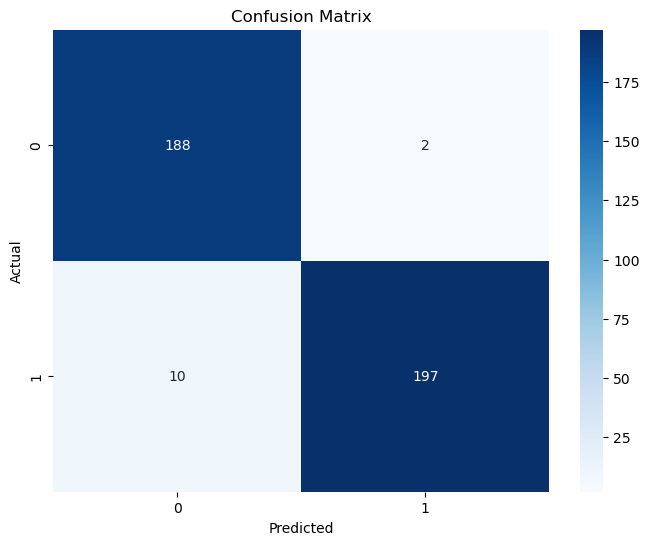

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()